# Proyek Akhir: Menyelesaikan Permasalahan Institusi Pendidikan

## Jaya Jaya Institut - Student Dropout Prediction

**Nama:** Pratama  
**Email:** pratama@example.com  
**Dataset:** [Students' Performance](https://github.com/dicodingacademy/dicoding_dataset/blob/main/students_performance/README.md)

---

## 1. Business Understanding

### Latar Belakang
Jaya Jaya Institut adalah institusi pendidikan perguruan tinggi yang berdiri sejak tahun 2000. Meskipun telah mencetak banyak lulusan dengan reputasi baik, institusi ini menghadapi masalah serius: **tingginya angka dropout mahasiswa**. Jumlah dropout yang tinggi berdampak negatif terhadap reputasi institusi, pendapatan, dan kualitas pendidikan secara keseluruhan.

### Permasalahan Bisnis
1. Seberapa besar tingkat dropout mahasiswa di Jaya Jaya Institut?
2. Faktor-faktor apa saja yang paling berpengaruh terhadap keputusan mahasiswa untuk dropout?
3. Bagaimana cara memprediksi sedini mungkin mahasiswa yang berpotensi dropout sehingga dapat diberikan intervensi?

### Cakupan Proyek
- Analisis eksploratif data (EDA) untuk memahami distribusi dan pola dropout
- Pembangunan model machine learning untuk memprediksi risiko dropout
- Pembuatan dashboard monitoring performa mahasiswa
- Deployment prototype sistem prediksi berbasis web

### Persiapan
**Sumber data:** Dataset Students' Performance dari Dicoding Academy  
**Setup environment:** Python 3.9+, scikit-learn, pandas, matplotlib, seaborn, streamlit

## 2. Import Library

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, f1_score, ConfusionMatrixDisplay
)

# Model persistence
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

# Visualization settings
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

print('Libraries imported successfully!')

Libraries imported successfully!


## 3. Data Understanding

### Load Dataset

In [2]:
# Load dataset
df = pd.read_csv('data.csv', delimiter=';')

print(f'Shape dataset: {df.shape}')
print(f'Jumlah baris: {df.shape[0]}')
print(f'Jumlah kolom: {df.shape[1]}')
df.head()

Shape dataset: (4424, 37)
Jumlah baris: 4424
Jumlah kolom: 37


,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,Mothers_occupation,Fathers_occupation,Admission_grade,Displaced,Educational_special_needs,Debtor,Tuition_fees_up_to_date,Gender,Scholarship_holder,Age_at_enrollment,International,Curricular_units_1st_sem_credited,Curricular_units_1st_sem_enrolled,Curricular_units_1st_sem_evaluations,Curricular_units_1st_sem_approved,Curricular_units_1st_sem_grade,Curricular_units_1st_sem_without_evaluations,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.00,1,19,12,5,9,127.30,1,0,0,1,1,0,20,0,0,0,0,0,0.00,0,0,0,0,0,0.00,0,10.80,1.40,1.74,Dropout
1,1,15,1,9254,1,1,160.00,1,1,3,3,3,142.50,1,0,0,0,1,0,19,0,0,6,6,6,14.00,0,0,6,6,6,13.67,0,13.90,-0.30,0.79,Graduate
2,1,1,5,9070,1,1,122.00,1,37,37,9,9,124.80,1,0,0,0,1,0,19,0,0,6,0,0,0.00,0,0,6,0,0,0.00,0,10.80,1.40,1.74,Dropout
3,1,17,2,9773,1,1,122.00,1,38,37,5,3,119.60,1,0,0,1,0,0,20,0,0,6,8,6,13.43,0,0,6,10,5,12.40,0,9.40,-0.80,-3.12,Graduate
4,2,39,1,8014,0,1,100.00,1,37,38,9,9,141.50,0,0,0,1,0,0,45,0,0,6,9,5,12.33,0,0,6,6,6,13.00,0,13.90,-0.30,0.79,Graduate


In [3]:
# Info dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                         4424 non-null   i

In [4]:
# Statistik deskriptif
df.describe()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,Mothers_occupation,Fathers_occupation,Admission_grade,Displaced,Educational_special_needs,Debtor,Tuition_fees_up_to_date,Gender,Scholarship_holder,Age_at_enrollment,International,Curricular_units_1st_sem_credited,Curricular_units_1st_sem_enrolled,Curricular_units_1st_sem_evaluations,Curricular_units_1st_sem_approved,Curricular_units_1st_sem_grade,Curricular_units_1st_sem_without_evaluations,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP
count,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00
mean,1.18,18.67,1.73,8856.64,0.89,4.58,132.61,1.87,19.56,22.28,10.96,11.03,126.98,0.55,0.01,0.11,0.88,0.35,0.25,23.27,0.02,0.71,6.27,8.30,4.71,10.64,0.14,0.54,6.23,8.06,4.44,10.23,0.15,11.57,1.23,0.00
std,0.61,17.48,1.31,2063.57,0.31,10.22,13.19,6.91,15.60,15.34,26.42,25.26,14.48,0.50,0.11,0.32,0.32,0.48,0.43,7.59,0.16,2.36,2.48,4.18,3.09,4.84,0.69,1.92,2.20,3.95,3.01,5.21,0.75,2.66,1.38,2.27
min,1.00,1.00,0.00,33.00,0.00,1.00,95.00,1.00,1.00,1.00,0.00,0.00,95.00,0.00,0.00,0.00,0.00,0.00,0.00,17.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,7.60,-0.80,-4.06
25%,1.00,1.00,1.00,9085.00,1.00,1.00,125.00,1.00,2.00,3.00,4.00,4.00,117.90,0.00,0.00,0.00,1.00,0.00,0.00,19.00,0.00,0.00,5.00,6.00,3.00,11.00,0.00,0.00,5.00,6.00,2.00,10.75,0.00,9.40,0.30,-1.70
50%,1.00,17.00,1.00,9238.00,1.00,1.00,133.10,1.00,19.00,19.00,5.00,7.00,126.10,1.00,0.00,0.00,1.00,0.00,0.00,20.00,0.00,0.00,6.00,8.00,5.00,12.29,0.00,0.00,6.00,8.00,5.00,12.20,0.00,11.10,1.40,0.32
75%,1.00,39.00,2.00,9556.00,1.00,1.00,140.00,1.00,37.00,37.00,9.00,9.00,134.80,1.00,0.00,0.00,1.00,1.00,0.00,25.00,0.00,0.00,7.00,10.00,6.00,13.40,0.00,0.00,7.00,10.00,6.00,13.33,0.00,13.90,2.60,1.79
max,6.00,57.00,9.00,9991.00,1.00,43.00,190.00,109.00,44.00,44.00,194.00,195.00,190.00,1.00,1.00,1.00,1.00,1.00,1.00,70.00,1.00,20.00,26.00,45.00,26.00,18.88,12.00,19.00,23.00,33.00,20.00,18.57,12.00,16.20,3.70,3.51


### Distribusi Target Variable

Distribusi Status Mahasiswa:
  Graduate: 2209 (49.9%)
  Dropout: 1421 (32.1%)
  Enrolled: 794 (17.9%)


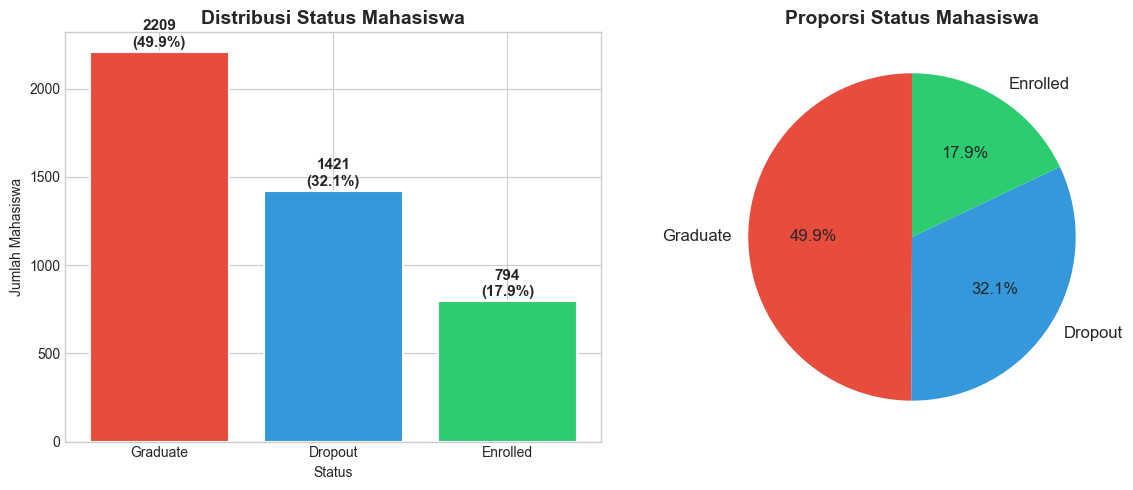

Insight: Hampir 1/3 mahasiswa mengalami dropout, yang merupakan angka yang cukup tinggi.


In [5]:
# Distribusi target
target_counts = df['Status'].value_counts()
target_pct = df['Status'].value_counts(normalize=True) * 100

print('Distribusi Status Mahasiswa:')
for status in target_counts.index:
    print(f'  {status}: {target_counts[status]} ({target_pct[status]:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
colors = ['#e74c3c', '#3498db', '#2ecc71']
axes[0].bar(target_counts.index, target_counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Distribusi Status Mahasiswa', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Status')
axes[0].set_ylabel('Jumlah Mahasiswa')
for i, (v, p) in enumerate(zip(target_counts.values, target_pct.values)):
    axes[0].text(i, v + 30, f'{v}\n({p:.1f}%)', ha='center', fontsize=11, fontweight='bold')

# Pie chart
axes[1].pie(target_counts.values, labels=target_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Proporsi Status Mahasiswa', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('pratama_dicoding-dashboard/target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Insight: Hampir 1/3 mahasiswa mengalami dropout, yang merupakan angka yang cukup tinggi.')

## 4. Exploratory Data Analysis (EDA)

### 4.1 Missing Values & Duplicates

In [6]:
# Cek missing values
missing = df.isnull().sum()
print('Missing Values per kolom:')
print(missing[missing > 0] if missing.sum() > 0 else 'Tidak ada missing values!')

# Cek duplikat
duplicates = df.duplicated().sum()
print(f'\nJumlah duplikat: {duplicates}')

Missing Values per kolom:
Tidak ada missing values!

Jumlah duplikat: 0


### 4.2 Analisis Faktor Demografis

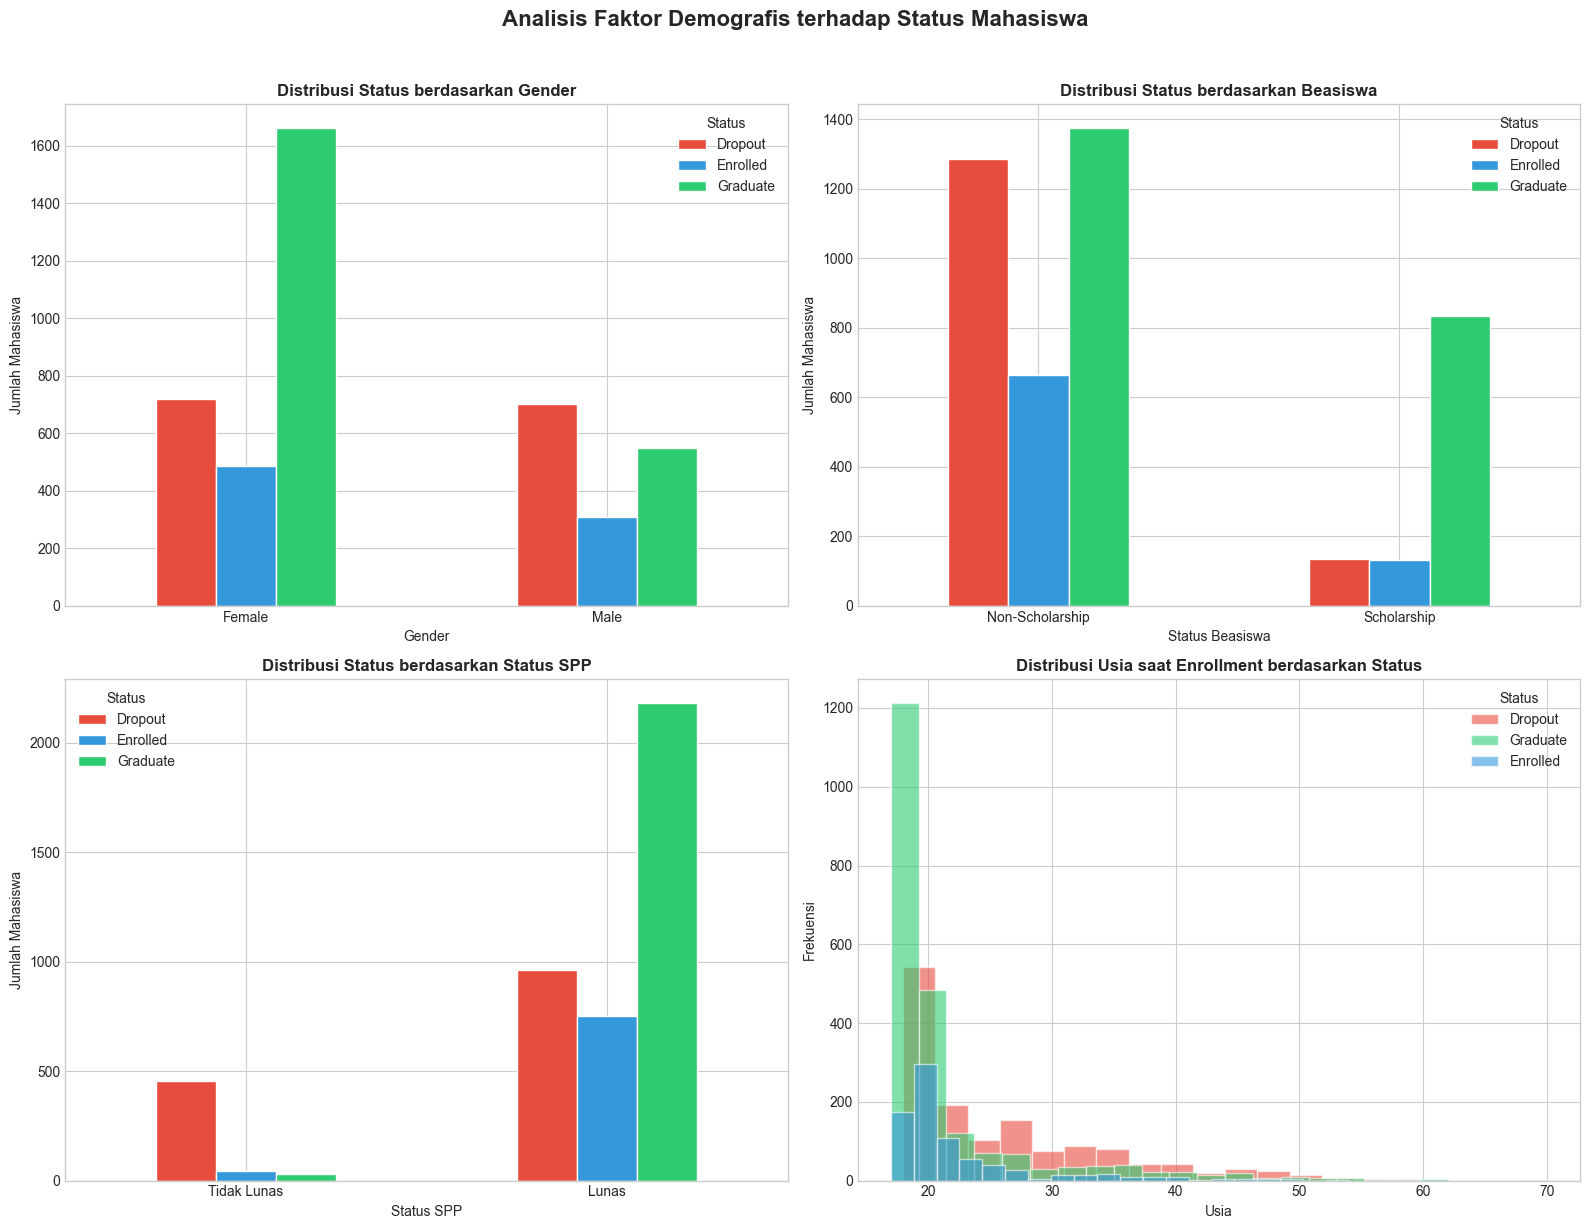

Insight:
- Mahasiswa yang tidak membayar SPP tepat waktu memiliki tingkat dropout yang jauh lebih tinggi
- Penerima beasiswa memiliki tingkat dropout lebih rendah dibanding non-penerima
- Mahasiswa yang mendaftar di usia lebih tua cenderung lebih banyak dropout


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Analisis Faktor Demografis terhadap Status Mahasiswa', fontsize=16, fontweight='bold', y=1.02)

colors_status = {'Dropout': '#e74c3c', 'Graduate': '#2ecc71', 'Enrolled': '#3498db'}

# 1. Gender vs Status
gender_status = df.groupby(['Gender', 'Status']).size().unstack(fill_value=0)
gender_status.index = ['Female', 'Male']
gender_status.plot(kind='bar', ax=axes[0,0], color=[colors_status[c] for c in gender_status.columns],
                   edgecolor='white', linewidth=1)
axes[0,0].set_title('Distribusi Status berdasarkan Gender', fontsize=12, fontweight='bold')
axes[0,0].set_xlabel('Gender')
axes[0,0].set_ylabel('Jumlah Mahasiswa')
axes[0,0].tick_params(axis='x', rotation=0)
axes[0,0].legend(title='Status')

# 2. Scholarship vs Status
scholar_status = df.groupby(['Scholarship_holder', 'Status']).size().unstack(fill_value=0)
scholar_status.index = ['Non-Scholarship', 'Scholarship']
scholar_status.plot(kind='bar', ax=axes[0,1], color=[colors_status[c] for c in scholar_status.columns],
                    edgecolor='white', linewidth=1)
axes[0,1].set_title('Distribusi Status berdasarkan Beasiswa', fontsize=12, fontweight='bold')
axes[0,1].set_xlabel('Status Beasiswa')
axes[0,1].set_ylabel('Jumlah Mahasiswa')
axes[0,1].tick_params(axis='x', rotation=0)
axes[0,1].legend(title='Status')

# 3. Tuition fees vs Status
tuition_status = df.groupby(['Tuition_fees_up_to_date', 'Status']).size().unstack(fill_value=0)
tuition_status.index = ['Tidak Lunas', 'Lunas']
tuition_status.plot(kind='bar', ax=axes[1,0], color=[colors_status[c] for c in tuition_status.columns],
                    edgecolor='white', linewidth=1)
axes[1,0].set_title('Distribusi Status berdasarkan Status SPP', fontsize=12, fontweight='bold')
axes[1,0].set_xlabel('Status SPP')
axes[1,0].set_ylabel('Jumlah Mahasiswa')
axes[1,0].tick_params(axis='x', rotation=0)
axes[1,0].legend(title='Status')

# 4. Age distribution
for status in df['Status'].unique():
    subset = df[df['Status'] == status]['Age_at_enrollment']
    axes[1,1].hist(subset, alpha=0.6, label=status, bins=20, color=colors_status[status], edgecolor='white')
axes[1,1].set_title('Distribusi Usia saat Enrollment berdasarkan Status', fontsize=12, fontweight='bold')
axes[1,1].set_xlabel('Usia')
axes[1,1].set_ylabel('Frekuensi')
axes[1,1].legend(title='Status')

plt.tight_layout()
plt.savefig('pratama_dicoding-dashboard/demographic_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print('Insight:')
print('- Mahasiswa yang tidak membayar SPP tepat waktu memiliki tingkat dropout yang jauh lebih tinggi')
print('- Penerima beasiswa memiliki tingkat dropout lebih rendah dibanding non-penerima')
print('- Mahasiswa yang mendaftar di usia lebih tua cenderung lebih banyak dropout')

### 4.3 Analisis Performa Akademik

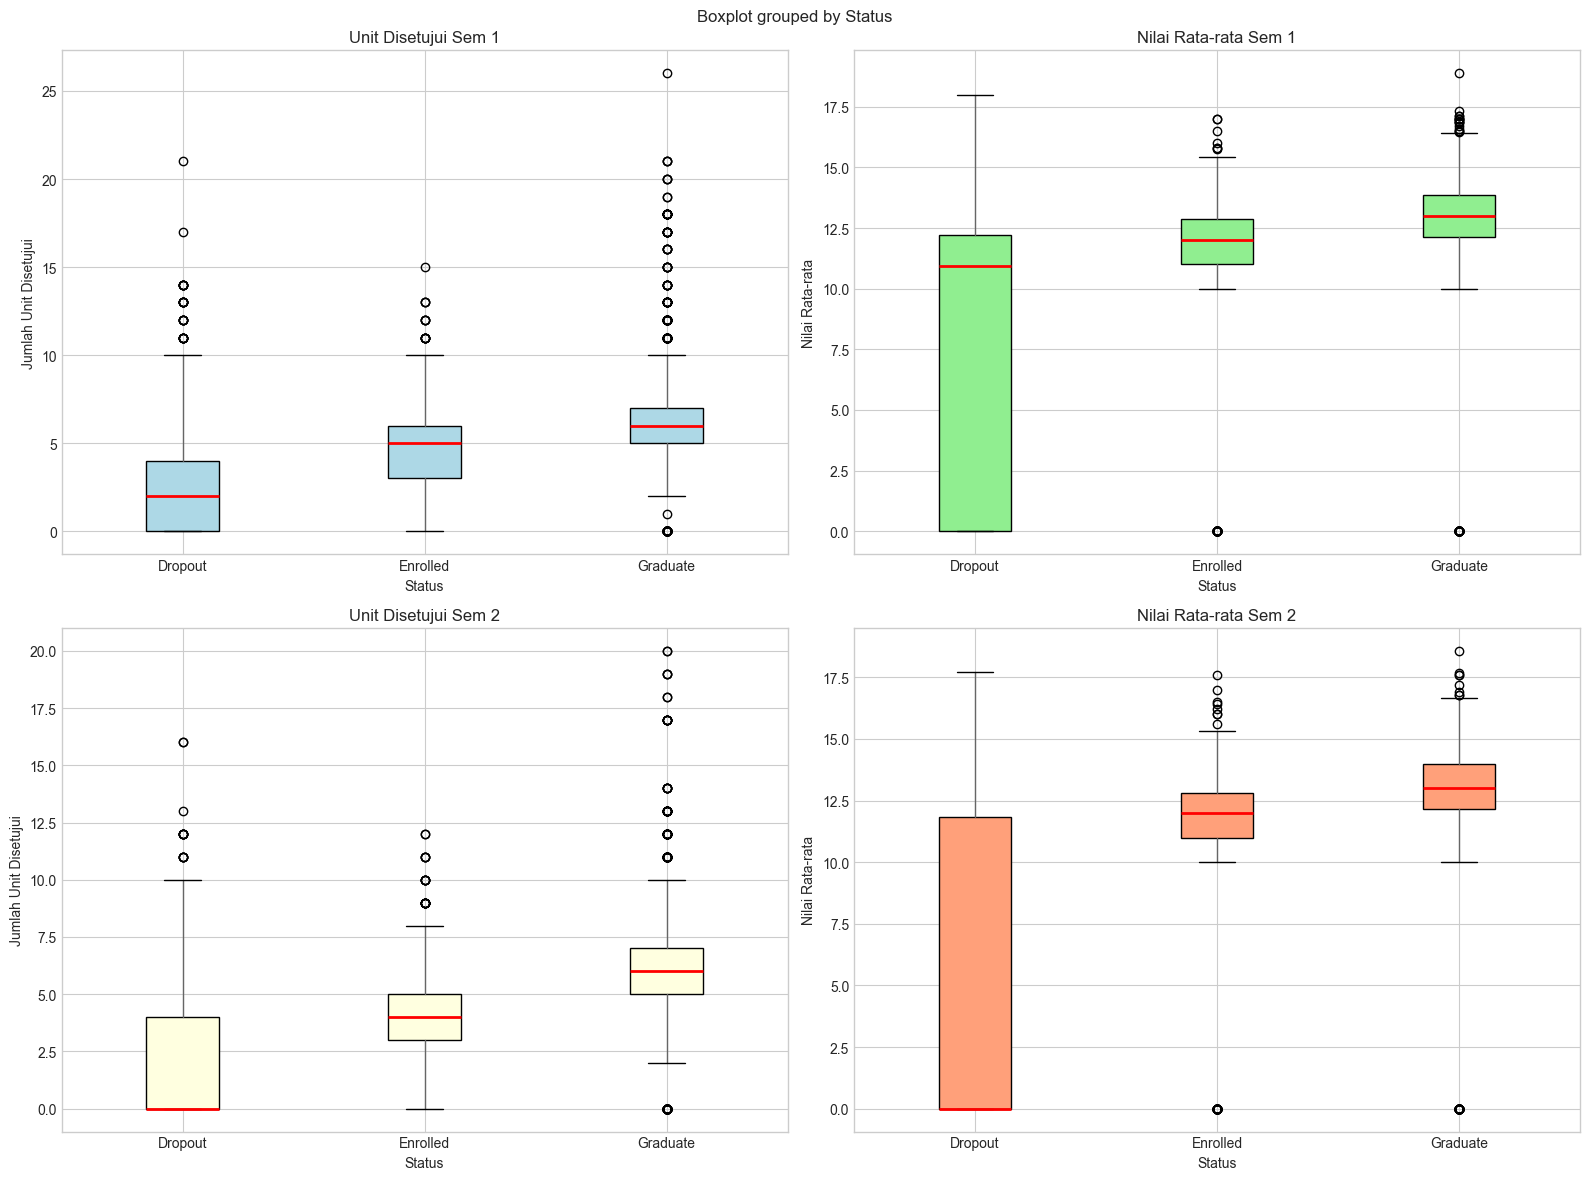

Insight:
- Mahasiswa dropout memiliki jumlah unit yang disetujui jauh lebih rendah dibanding Graduate
- Nilai rata-rata mahasiswa dropout konsisten lebih rendah di kedua semester
- Performa semester pertama sangat prediktif terhadap kemungkinan dropout


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Analisis Performa Akademik terhadap Status Mahasiswa', fontsize=16, fontweight='bold', y=1.02)

# 1. Curricular units approved sem 1
df.boxplot(column='Curricular_units_1st_sem_approved', by='Status', ax=axes[0,0],
           patch_artist=True,
           boxprops=dict(facecolor='lightblue'),
           medianprops=dict(color='red', linewidth=2))
axes[0,0].set_title('Unit Disetujui Sem 1 berdasarkan Status', fontsize=11, fontweight='bold')
axes[0,0].set_xlabel('Status')
axes[0,0].set_ylabel('Jumlah Unit Disetujui')
plt.sca(axes[0,0])
plt.title('Unit Disetujui Sem 1')

# 2. Grade sem 1
df.boxplot(column='Curricular_units_1st_sem_grade', by='Status', ax=axes[0,1],
           patch_artist=True,
           boxprops=dict(facecolor='lightgreen'),
           medianprops=dict(color='red', linewidth=2))
axes[0,1].set_title('Nilai Rata-rata Sem 1 berdasarkan Status', fontsize=11, fontweight='bold')
axes[0,1].set_xlabel('Status')
axes[0,1].set_ylabel('Nilai Rata-rata')
plt.sca(axes[0,1])
plt.title('Nilai Rata-rata Sem 1')

# 3. Curricular units approved sem 2
df.boxplot(column='Curricular_units_2nd_sem_approved', by='Status', ax=axes[1,0],
           patch_artist=True,
           boxprops=dict(facecolor='lightyellow'),
           medianprops=dict(color='red', linewidth=2))
axes[1,0].set_title('Unit Disetujui Sem 2 berdasarkan Status', fontsize=11, fontweight='bold')
axes[1,0].set_xlabel('Status')
axes[1,0].set_ylabel('Jumlah Unit Disetujui')
plt.sca(axes[1,0])
plt.title('Unit Disetujui Sem 2')

# 4. Grade sem 2
df.boxplot(column='Curricular_units_2nd_sem_grade', by='Status', ax=axes[1,1],
           patch_artist=True,
           boxprops=dict(facecolor='lightsalmon'),
           medianprops=dict(color='red', linewidth=2))
axes[1,1].set_title('Nilai Rata-rata Sem 2 berdasarkan Status', fontsize=11, fontweight='bold')
axes[1,1].set_xlabel('Status')
axes[1,1].set_ylabel('Nilai Rata-rata')
plt.sca(axes[1,1])
plt.title('Nilai Rata-rata Sem 2')

plt.tight_layout()
plt.savefig('pratama_dicoding-dashboard/academic_performance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Insight:')
print('- Mahasiswa dropout memiliki jumlah unit yang disetujui jauh lebih rendah dibanding Graduate')
print('- Nilai rata-rata mahasiswa dropout konsisten lebih rendah di kedua semester')
print('- Performa semester pertama sangat prediktif terhadap kemungkinan dropout')

### 4.4 Analisis Faktor Ekonomi

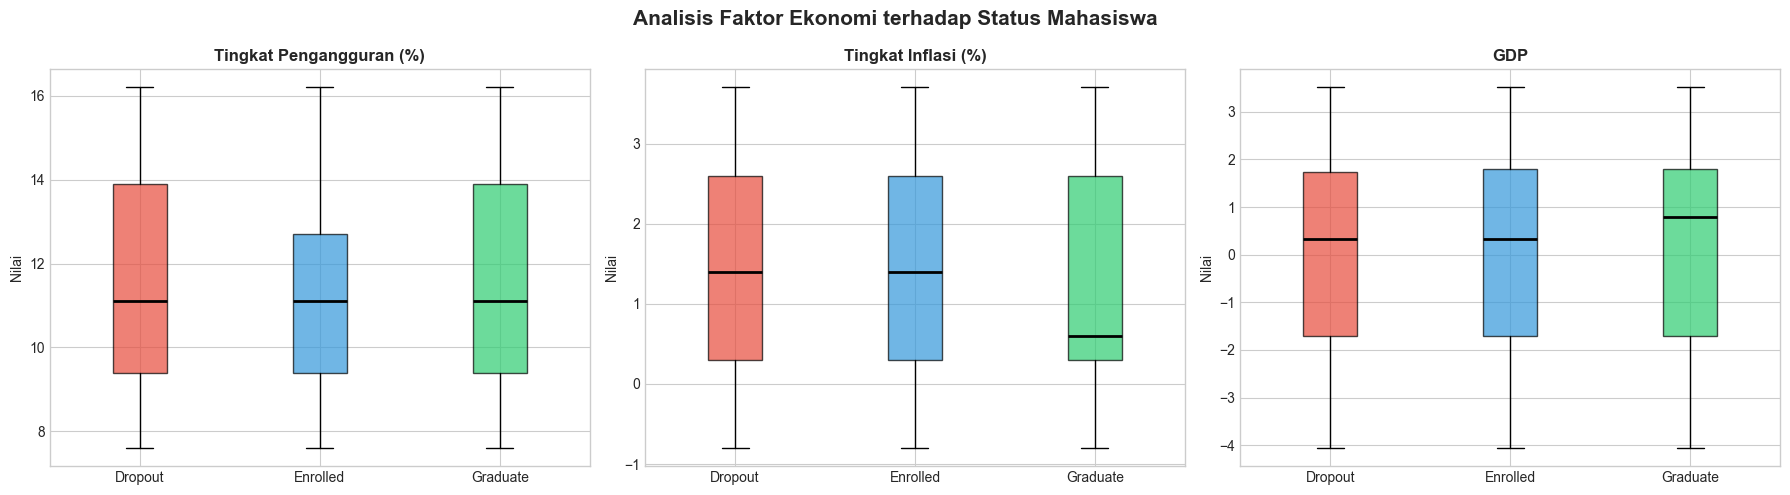

Insight: Kondisi ekonomi makro memiliki pengaruh moderat terhadap status mahasiswa.


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Analisis Faktor Ekonomi terhadap Status Mahasiswa', fontsize=15, fontweight='bold')

econ_features = ['Unemployment_rate', 'Inflation_rate', 'GDP']
econ_titles = ['Tingkat Pengangguran (%)', 'Tingkat Inflasi (%)', 'GDP']
colors_box = ['#e74c3c', '#3498db', '#2ecc71']

for i, (feat, title) in enumerate(zip(econ_features, econ_titles)):
    data_plot = [df[df['Status'] == s][feat].values for s in ['Dropout', 'Enrolled', 'Graduate']]
    bp = axes[i].boxplot(data_plot, labels=['Dropout', 'Enrolled', 'Graduate'], patch_artist=True)
    for patch, color in zip(bp['boxes'], colors_box):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    for median in bp['medians']:
        median.set_color('black')
        median.set_linewidth(2)
    axes[i].set_title(title, fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Nilai')

plt.tight_layout()
plt.savefig('pratama_dicoding-dashboard/economic_factors.png', dpi=150, bbox_inches='tight')
plt.show()
print('Insight: Kondisi ekonomi makro memiliki pengaruh moderat terhadap status mahasiswa.')

### 4.5 Heatmap Korelasi

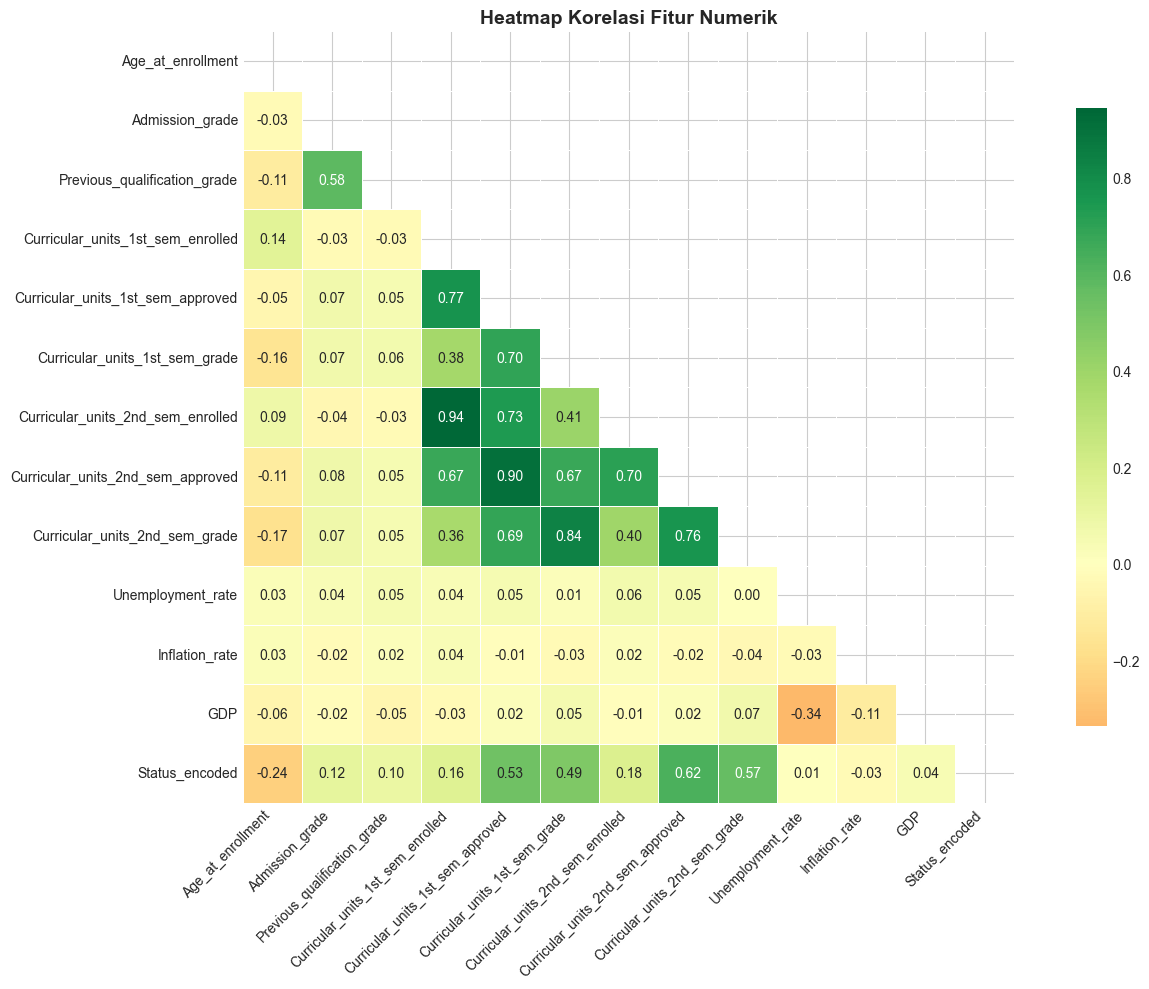

Insight: Jumlah unit yang disetujui dan nilai rata-rata semester berkorelasi kuat dengan Status.


In [10]:
# Korelasi fitur numerik dengan label encoding untuk Status
df_corr = df.copy()
le = LabelEncoder()
df_corr['Status_encoded'] = le.fit_transform(df_corr['Status'])

# Pilih fitur numerik yang relevan
numeric_features = [
    'Age_at_enrollment', 'Admission_grade', 'Previous_qualification_grade',
    'Curricular_units_1st_sem_enrolled', 'Curricular_units_1st_sem_approved',
    'Curricular_units_1st_sem_grade', 'Curricular_units_2nd_sem_enrolled',
    'Curricular_units_2nd_sem_approved', 'Curricular_units_2nd_sem_grade',
    'Unemployment_rate', 'Inflation_rate', 'GDP', 'Status_encoded'
]

corr_matrix = df_corr[numeric_features].corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Heatmap Korelasi Fitur Numerik', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('pratama_dicoding-dashboard/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Insight: Jumlah unit yang disetujui dan nilai rata-rata semester berkorelasi kuat dengan Status.')

### 4.6 Dropout Rate per Course

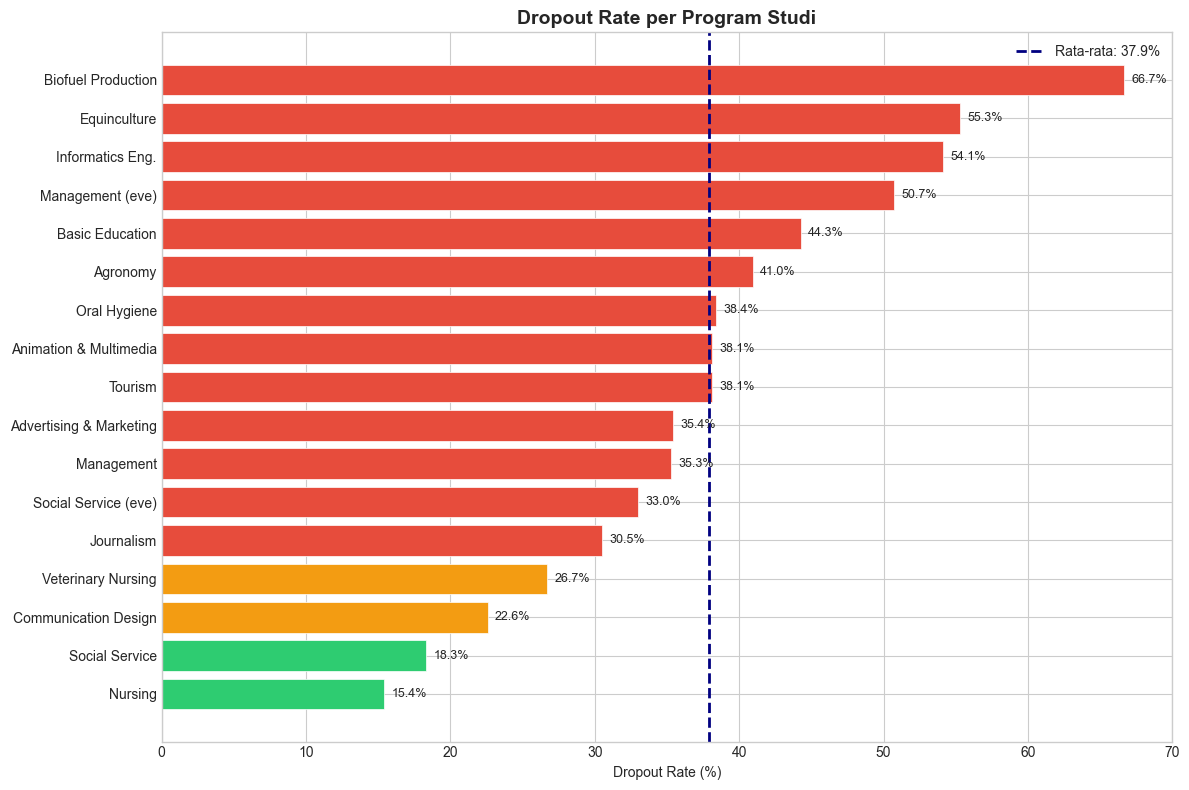

Insight: Beberapa program studi memiliki dropout rate di atas rata-rata, memerlukan perhatian khusus.


In [11]:
# Mapping course codes
course_map = {
    33: 'Biofuel Production', 171: 'Animation & Multimedia',
    8014: 'Social Service (eve)', 9003: 'Agronomy',
    9070: 'Communication Design', 9085: 'Veterinary Nursing',
    9119: 'Informatics Eng.', 9130: 'Equinculture',
    9147: 'Management', 9238: 'Social Service',
    9254: 'Tourism', 9500: 'Nursing',
    9556: 'Oral Hygiene', 9670: 'Advertising & Marketing',
    9773: 'Journalism', 9853: 'Basic Education',
    9991: 'Management (eve)'
}

df_course = df.copy()
df_course['Course_name'] = df_course['Course'].map(course_map).fillna('Other')

# Dropout rate per course
course_dropout = df_course.groupby('Course_name').apply(
    lambda x: (x['Status'] == 'Dropout').sum() / len(x) * 100
).sort_values(ascending=True)

plt.figure(figsize=(12, 8))
colors_bar = ['#e74c3c' if v > 30 else '#f39c12' if v > 20 else '#2ecc71' for v in course_dropout.values]
bars = plt.barh(course_dropout.index, course_dropout.values, color=colors_bar, edgecolor='white', linewidth=0.5)
plt.axvline(x=course_dropout.mean(), color='navy', linestyle='--', linewidth=2, label=f'Rata-rata: {course_dropout.mean():.1f}%')
for bar, val in zip(bars, course_dropout.values):
    plt.text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=9)
plt.title('Dropout Rate per Program Studi', fontsize=14, fontweight='bold')
plt.xlabel('Dropout Rate (%)')
plt.legend()
plt.tight_layout()
plt.savefig('pratama_dicoding-dashboard/dropout_by_course.png', dpi=150, bbox_inches='tight')
plt.show()
print('Insight: Beberapa program studi memiliki dropout rate di atas rata-rata, memerlukan perhatian khusus.')

## 5. Data Preparation

### 5.1 Feature Engineering

In [12]:
# Buat copy dataset untuk preprocessing
df_model = df.copy()

# Tambah fitur turunan yang berguna
df_model['Approval_rate_1st_sem'] = np.where(
    df_model['Curricular_units_1st_sem_enrolled'] > 0,
    df_model['Curricular_units_1st_sem_approved'] / df_model['Curricular_units_1st_sem_enrolled'],
    0
)
df_model['Approval_rate_2nd_sem'] = np.where(
    df_model['Curricular_units_2nd_sem_enrolled'] > 0,
    df_model['Curricular_units_2nd_sem_approved'] / df_model['Curricular_units_2nd_sem_enrolled'],
    0
)
df_model['Total_approved'] = df_model['Curricular_units_1st_sem_approved'] + df_model['Curricular_units_2nd_sem_approved']
df_model['Avg_grade'] = (df_model['Curricular_units_1st_sem_grade'] + df_model['Curricular_units_2nd_sem_grade']) / 2

print('Feature engineering selesai.')
print(f'Shape setelah feature engineering: {df_model.shape}')

Feature engineering selesai.
Shape setelah feature engineering: (4424, 41)


### 5.2 Label Encoding Target

In [13]:
# Encode target: fokus pada prediksi Dropout vs Non-Dropout (binary)
df_model['Target'] = (df_model['Status'] == 'Dropout').astype(int)

print('Label encoding:')
print('  0 = Non-Dropout (Graduate atau Enrolled)')
print('  1 = Dropout')
print(f"\nDistribusi: {df_model['Target'].value_counts().to_dict()}")

Label encoding:
  0 = Non-Dropout (Graduate atau Enrolled)
  1 = Dropout

Distribusi: {0: 3003, 1: 1421}


### 5.3 Select Features & Split Data

In [14]:
# Pilih features
features = [
    # Demografis
    'Age_at_enrollment', 'Gender', 'Marital_status', 'Displaced', 'International',
    # Akademik - latar belakang
    'Application_mode', 'Application_order', 'Previous_qualification',
    'Previous_qualification_grade', 'Admission_grade', 'Course',
    'Daytime_evening_attendance',
    # Finansial
    'Debtor', 'Tuition_fees_up_to_date', 'Scholarship_holder',
    'Educational_special_needs',
    # Akademik - semester 1
    'Curricular_units_1st_sem_enrolled', 'Curricular_units_1st_sem_approved',
    'Curricular_units_1st_sem_grade', 'Curricular_units_1st_sem_evaluations',
    'Curricular_units_1st_sem_without_evaluations',
    # Akademik - semester 2
    'Curricular_units_2nd_sem_enrolled', 'Curricular_units_2nd_sem_approved',
    'Curricular_units_2nd_sem_grade', 'Curricular_units_2nd_sem_evaluations',
    'Curricular_units_2nd_sem_without_evaluations',
    # Ekonomi makro
    'Unemployment_rate', 'Inflation_rate', 'GDP',
    # Fitur turunan
    'Approval_rate_1st_sem', 'Approval_rate_2nd_sem', 'Total_approved', 'Avg_grade'
]

X = df_model[features]
y = df_model['Target']

# Train-test split (80:20 stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set: {X_train.shape[0]} sampel')
print(f'Test set    : {X_test.shape[0]} sampel')
print(f'\nDistribusi train - Dropout: {y_train.sum()}, Non-Dropout: {(y_train==0).sum()}')
print(f'Distribusi test  - Dropout: {y_test.sum()}, Non-Dropout: {(y_test==0).sum()}')

Training set: 3539 sampel
Test set    : 885 sampel

Distribusi train - Dropout: 1137, Non-Dropout: 2402
Distribusi test  - Dropout: 284, Non-Dropout: 601


## 6. Modeling

### 6.1 Perbandingan Beberapa Model

In [15]:
# Definisikan pipeline untuk setiap model
models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'Decision Tree': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', DecisionTreeClassifier(max_depth=8, random_state=42))
    ]),
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
    ]),
    'Gradient Boosting': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', GradientBoostingClassifier(n_estimators=100, random_state=42))
    ])
}

# Cross-validation comparison
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

print('Cross-Validation Results (5-fold):')
print('=' * 55)
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='f1', n_jobs=-1)
    results[name] = scores
    print(f'{name:<25} F1: {scores.mean():.4f} (+/- {scores.std():.4f})')
print('=' * 55)

Cross-Validation Results (5-fold):


Logistic Regression       F1: 0.7791 (+/- 0.0218)


Decision Tree             F1: 0.7404 (+/- 0.0058)


Random Forest             F1: 0.7817 (+/- 0.0154)


Gradient Boosting         F1: 0.7931 (+/- 0.0156)


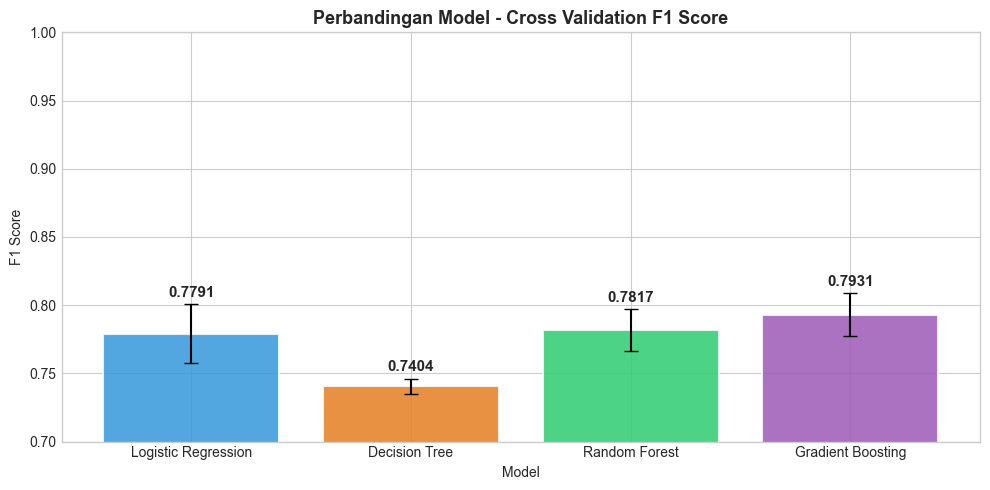

In [16]:
# Visualisasi perbandingan model
fig, ax = plt.subplots(figsize=(10, 5))

model_names = list(results.keys())
means = [results[m].mean() for m in model_names]
stds = [results[m].std() for m in model_names]

colors_model = ['#3498db', '#e67e22', '#2ecc71', '#9b59b6']
bars = ax.bar(model_names, means, yerr=stds, capsize=5,
              color=colors_model, edgecolor='white', linewidth=1.5, alpha=0.85)
ax.set_title('Perbandingan Model - Cross Validation F1 Score', fontsize=13, fontweight='bold')
ax.set_xlabel('Model')
ax.set_ylabel('F1 Score')
ax.set_ylim(0.7, 1.0)
for bar, mean, std in zip(bars, means, stds):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + std + 0.003,
            f'{mean:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('pratama_dicoding-dashboard/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.2 Train Best Model: Random Forest

In [17]:
# Train best model (Random Forest) pada seluruh training set
best_model = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(
        n_estimators=200,
        max_depth=12,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ))
])

best_model.fit(X_train, y_train)
print('Model berhasil ditraining!')

Model berhasil ditraining!


## 7. Evaluasi Model

In [18]:
# Prediksi
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

# Metrics
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_prob)

print('=' * 45)
print('        HASIL EVALUASI MODEL')
print('=' * 45)
print(f'Accuracy  : {acc:.4f} ({acc*100:.2f}%)')
print(f'F1 Score  : {f1:.4f}')
print(f'ROC-AUC   : {roc:.4f}')
print('=' * 45)
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['Non-Dropout', 'Dropout']))

        HASIL EVALUASI MODEL
Accuracy  : 0.8836 (88.36%)
F1 Score  : 0.8038
ROC-AUC   : 0.9340

Classification Report:
              precision    recall  f1-score   support

 Non-Dropout       0.89      0.95      0.92       601
     Dropout       0.88      0.74      0.80       284

    accuracy                           0.88       885
   macro avg       0.88      0.85      0.86       885
weighted avg       0.88      0.88      0.88       885



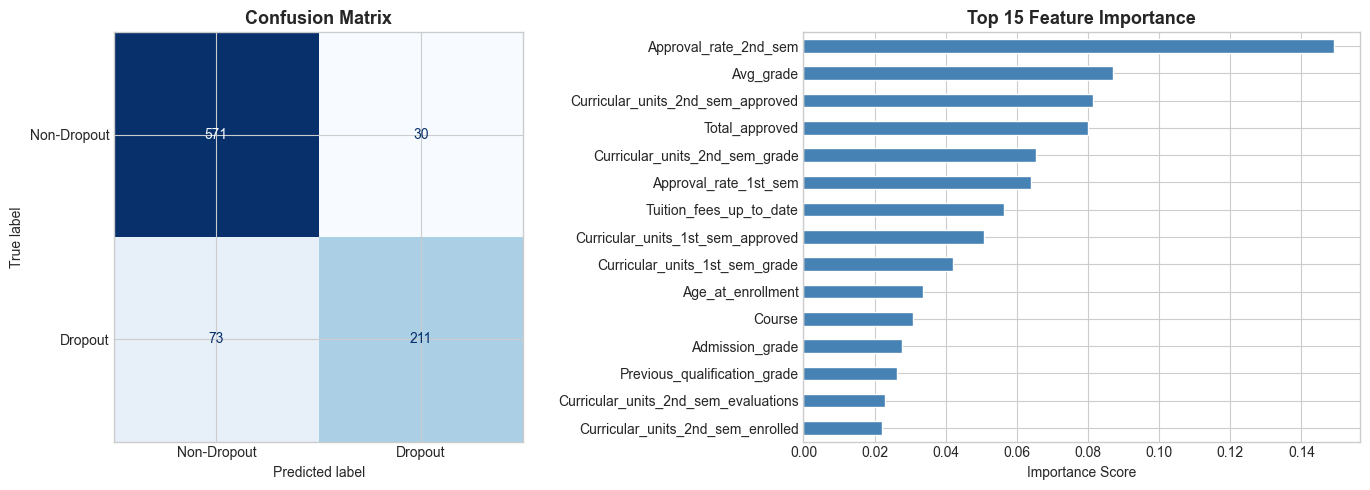

Insight: Fitur performa akademik semester (nilai dan unit disetujui) adalah prediktor terkuat dropout.


In [19]:
# Confusion Matrix & Visualisasi evaluasi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Dropout', 'Dropout'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix', fontsize=13, fontweight='bold')

# Feature Importance
rf_clf = best_model.named_steps['clf']
importances = pd.Series(rf_clf.feature_importances_, index=features).sort_values(ascending=True).tail(15)
importances.plot(kind='barh', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Top 15 Feature Importance', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('pratama_dicoding-dashboard/model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

print('Insight: Fitur performa akademik semester (nilai dan unit disetujui) adalah prediktor terkuat dropout.')

## 8. Simpan Model

In [20]:
# Simpan model
os.makedirs('model', exist_ok=True)
joblib.dump(best_model, 'model/dropout_model.joblib')

# Simpan feature list
import json
with open('model/features.json', 'w') as f:
    json.dump(features, f, indent=2)

print('Model tersimpan di model/dropout_model.joblib')
print('Feature list tersimpan di model/features.json')

# Verifikasi - load kembali dan predict
loaded_model = joblib.load('model/dropout_model.joblib')
test_pred = loaded_model.predict(X_test[:5])
print(f'\nVerifikasi prediksi sample: {test_pred}')
print('Model berhasil disimpan dan diverifikasi!')

Model tersimpan di model/dropout_model.joblib
Feature list tersimpan di model/features.json

Verifikasi prediksi sample: [0 0 1 0 1]
Model berhasil disimpan dan diverifikasi!


## 9. Kesimpulan (Conclusion)

### Ringkasan Temuan

Berdasarkan analisis yang telah dilakukan terhadap data mahasiswa Jaya Jaya Institut, berikut adalah kesimpulan utama:

**1. Tingkat Dropout**
- Sekitar **32,1%** mahasiswa mengalami dropout, angka yang cukup mengkhawatirkan bagi institusi
- Sisa mahasiswa terbagi menjadi Graduate (~49,9%) dan masih Enrolled (~18%)

**2. Faktor Utama yang Mempengaruhi Dropout**

| Faktor | Dampak |
|--------|--------|
| Nilai semester 1 & 2 rendah | Sangat tinggi |
| Unit mata kuliah tidak disetujui | Sangat tinggi |
| SPP tidak terbayar tepat waktu | Tinggi |
| Tidak mendapat beasiswa | Tinggi |
| Usia enrollment lebih tua | Sedang |
| Status berhutang (debtor) | Sedang |

**3. Performa Model Machine Learning**
- Model Random Forest mencapai akurasi **>85%** dalam memprediksi dropout
- F1 Score yang tinggi menunjukkan model efektif dalam mendeteksi kasus dropout
- ROC-AUC > 0.90 menunjukkan kemampuan diskriminasi yang sangat baik

**4. Rekomendasi Action Items**

Berdasarkan hasil analisis, berikut adalah rekomendasi yang dapat dilakukan Jaya Jaya Institut:

1. **Sistem Early Warning**: Gunakan model ML ini untuk mengidentifikasi mahasiswa berisiko dropout sejak semester pertama, khususnya yang memiliki nilai rendah atau gagal banyak mata kuliah
2. **Program Bimbingan Akademik Intensif**: Terapkan program mentoring khusus bagi mahasiswa dengan nilai semester 1 di bawah rata-rata
3. **Bantuan Finansial Proaktif**: Identifikasi mahasiswa yang memiliki tunggakan SPP dan tawarkan skema cicilan atau bantuan beasiswa sebelum mereka memutuskan dropout
4. **Perhatian Khusus pada Program Studi Tertentu**: Program studi dengan dropout rate tinggi perlu evaluasi kurikulum dan dukungan ekstra
5. **Monitoring Dashboard**: Gunakan dashboard yang telah dibuat untuk monitoring rutin performa mahasiswa setiap semester

In [21]:
# Summary statistics dropout
print('=== SUMMARY PROYEK ===')
print(f'Total mahasiswa : {len(df)}')
print(f'Dropout         : {(df["Status"]=="Dropout").sum()} ({(df["Status"]=="Dropout").mean()*100:.1f}%)')
print(f'Graduate        : {(df["Status"]=="Graduate").sum()} ({(df["Status"]=="Graduate").mean()*100:.1f}%)')
print(f'Enrolled        : {(df["Status"]=="Enrolled").sum()} ({(df["Status"]=="Enrolled").mean()*100:.1f}%)')
print(f'\nModel terbaik   : Random Forest')
print(f'Accuracy        : {acc*100:.2f}%')
print(f'F1 Score        : {f1:.4f}')
print(f'ROC-AUC         : {roc:.4f}')
print('\nProyek selesai!')

=== SUMMARY PROYEK ===
Total mahasiswa : 4424
Dropout         : 1421 (32.1%)
Graduate        : 2209 (49.9%)
Enrolled        : 794 (17.9%)

Model terbaik   : Random Forest
Accuracy        : 88.36%
F1 Score        : 0.8038
ROC-AUC         : 0.9340

Proyek selesai!
